# **Identifikasi Risiko Kambuhnya Asma di Tiga Titik Lokasi UPH Menggunakan Algoritma Random Forest dan Naive Bayes**

## **Tujuan Proyek**

Proyek ini bertujuan untuk **mengklasifikasikan area yang kami tentukan di Universitas Pelita Harapan (UPH)** berdasarkan **tingkat risiko kambuhnya penyakit asma**. Hal ini dilakukan dengan menganalisis data lingkungan seperti **suhu, kelembapan, dan gas** yang dikumpulkan dari tiga titik utama:
*   Food Junction
*   Johannes Oentoro Library
*   Kelas

Tujuan akhirnya adalah:
*   Mengetahui **lokasi mana yang paling aman dan paling berisiko** bagi penderita asma
*   Memberikan informasi berbasis data agar mahasiswa dan staf yang memiliki risiko asma dapat **menghindari area berisiko tinggi**

## **Perangkat yang Digunakan**

Data dikumpulkan menggunakan perangkat **IoT** berbasis **ESP32 / ESP8266**. Perangkat keras yang digunakan antara lain:
*   **ESP8266 / ESP32** sebagai mikrokontroler
*   **Sensor DHT11** untuk mengukur suhu dan kelembapan
*   **Sensor MQ135** untuk mendeteksi konsentrasi gas/polutan
*   **LCD 12IC** untuk menampilkan data real-time

Data dikirim secara berkala ke server melalui koneksi WiFi dan disimpan dalam database cloud.


## **Metodologi**

1.   **Pengumpulan Data** - Data suhu, kelembapan, dan gas dikumpulkan setiap 15 detik di 3 lokasi berbeda.
2. **Pre-processing Data** - Kalibrasi Nilai gas, Memeriksa Data duplikat dan Missing Values.

3.   **Labeling Risiko Asma** - Berdasarkan nilai ambang batas tertentu, data dilabeli sebagai:
*   **Tidak Berisiko**
*   **Berisiko**
4.   **Machine Learning** - Dua algoritma klasifikasi digunakan:
*   **Random Forest**: untuk mengklasifikasikan lokasi berdasarkan data sensor
*   **Naive Bayes**: untuk mengklasifikasikan tingkat risiko asma
5.   **Evaluasi dan Analisis** -  Dilakukan evaluasi model berdasarkan akurasi, classification report, dan confusion matrix, serta analisis distribusi risiko asma per lokasi.

## **Hasil yang Diharapkan**

*   Menyediakan **informasi lokasi yang aman dan tidak aman bagi penderita asma**
*   Menjadi **dasar pengambilan keputusan** bagi pihak kampus terkait perbaikan kualitas udara
*   Meningkatkan **kesadaran akan polusi udara lokal** di area kampus


## **Pengumpulan Data & *Preprocessing***

### **Import Library & Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics as met
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy import stats

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving food_junction.csv to food_junction.csv
Saving kelas.csv to kelas.csv
Saving library.csv to library.csv


In [ ]:
# Load Data
fj = pd.read_csv("food_junction.csv")
lib = pd.read_csv("library.csv")
kelas = pd.read_csv("kelas.csv")

Menambahkan kolom lokasi

In [ ]:
# Tambahkan kolom lokasi
fj["lokasi"] = "food_junction"
lib["lokasi"] = "library"
kelas["lokasi"] = "kelas"

### **Kalibrasi Nilai Gas**

Karena data dari **Food Junction** sebagian menggunakan ESP32 dan sebagian menggunakan ESP8266, dilakukan **kalibrasi nilai gas** agar semua data memiliki standar yang sama dengan ESP8266.



> Kalibrasi diperlukan karena nilai ADC yang dibaca dari sensor gas MQ135 berbeda tergantung pada jenis mikrokontroler yang digunakan. ESP32 memiliki ADC 12-bit, sedangkan ESP8266 memiliki ADC 10-bit.



Menambah kolom `tipe_esp` di data FJ, di mana data dengan **ID 1-1425** ditandai **esp32**, dan data dengan **ID 1425-1720** ditandai **esp8266**

In [ ]:
# ID < 1425 dianggap ESP32, lainnya ESP8266, menandai tipe esp
fj["tipe_esp"] = fj["id"].apply(lambda x: "esp32" if x <= 1425 else "esp8266")

In [ ]:
fj

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp
0,1,29.8,67,694,58:02.4,food_junction,esp32
1,2,29.8,67,687,58:06.3,food_junction,esp32
2,3,29.8,67,702,58:11.4,food_junction,esp32
3,4,29.8,67,683,58:16.6,food_junction,esp32
4,5,29.8,67,675,58:21.4,food_junction,esp32
...,...,...,...,...,...,...,...
1715,1716,28.1,84,213,32:28.5,food_junction,esp8266
1716,1717,28.1,84,213,32:43.7,food_junction,esp8266
1717,1718,28.1,83,212,32:59.1,food_junction,esp8266
1718,1719,28.1,83,213,33:14.2,food_junction,esp8266


Oleh karena itu, kalibrasi dilakukan untuk menyamakan skala pembacaan antara ESP32 dan ESP8266 menggunakan pendekatan linear (interpolasi):

In [ ]:
def scale_esp32_to_esp8266(gas_value):
    return 198 + ((gas_value - 354) / (803 - 354)) * (354 - 198)

mask_esp32 = fj["tipe_esp"] == "esp32"
fj.loc[mask_esp32, "gas"] = fj.loc[mask_esp32, "gas"].apply(scale_esp32_to_esp8266)


/tmp/ipython-input-7-2533852190.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[316.12917595 313.69710468 318.90868597 ... 280.34298441 257.75946548
 242.47216036]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fj.loc[mask_esp32, "gas"] = fj.loc[mask_esp32, "gas"].apply(scale_esp32_to_esp8266)


In [ ]:
fj

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp
0,1,29.8,67,316.129176,58:02.4,food_junction,esp32
1,2,29.8,67,313.697105,58:06.3,food_junction,esp32
2,3,29.8,67,318.908686,58:11.4,food_junction,esp32
3,4,29.8,67,312.307350,58:16.6,food_junction,esp32
4,5,29.8,67,309.527840,58:21.4,food_junction,esp32
...,...,...,...,...,...,...,...
1715,1716,28.1,84,213.000000,32:28.5,food_junction,esp8266
1716,1717,28.1,84,213.000000,32:43.7,food_junction,esp8266
1717,1718,28.1,83,212.000000,32:59.1,food_junction,esp8266
1718,1719,28.1,83,213.000000,33:14.2,food_junction,esp8266


Setelah dikalibrasi, semua data FJ sudah memiliki range yang sama

Menambahkan kolom tipe_esp kepada setiap dataset dan mengisinya dengan esp8266

In [ ]:
fj["tipe_esp"] = "esp8266"
lib["tipe_esp"] = "esp8266"
kelas["tipe_esp"] = "esp8266"

Ketiga dataset digabung menjadi satu dataset `data`

In [ ]:
data = pd.concat([fj, lib, kelas], ignore_index=True)

In [ ]:
data

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp
0,1,29.8,67,316.129176,58:02.4,food_junction,esp8266
1,2,29.8,67,313.697105,58:06.3,food_junction,esp8266
2,3,29.8,67,318.908686,58:11.4,food_junction,esp8266
3,4,29.8,67,312.307350,58:16.6,food_junction,esp8266
4,5,29.8,67,309.527840,58:21.4,food_junction,esp8266
...,...,...,...,...,...,...,...
5155,1784,22.6,69,182.000000,44:40.0,kelas,esp8266
5156,1785,22.6,69,182.000000,44:55.0,kelas,esp8266
5157,1786,22.6,69,182.000000,45:10.2,kelas,esp8266
5158,1787,22.6,69,182.000000,45:25.5,kelas,esp8266


### **Memeriksa Data Duplikat dan Missing Values**

In [ ]:
#periksa data duplikat
print('jumlah data yang duplikat:', data.duplicated().sum())

jumlah data yang duplikat: 0


In [ ]:
#missing value
print('jumlah data yang hilang/null')
data.isnull().sum()

jumlah data yang hilang/null


,0
id,0
suhu,0
kelembapan,0
gas,0
waktu,0
lokasi,0
tipe_esp,0


### **Menambahkan Label Kualitas Udara Berdasarkan Parameter**

Untuk memudahkan analisis dan klasifikasi, kita memberi **label kualitas pada setiap parameter lingkungan: suhu, kelembapan, dan gas** berdasarkan rentang yang dianggap ideal bagi kesehatan, terutama untuk penderita asma:


1.   **Kualitas Suhu:** Suhu dianggap baik (1) jika berada dalam rentang **14.8°C hingga 30°C**, yaitu rentang nyaman bagi aktivitas manusia dan relatif aman untuk pernapasan. Di luar rentang ini, diberi label buruk (0).
2.   **Kualitas Kelembapan:** Kelembapan **ideal** berada pada rentang **40% hingga 60%**, yang membantu menjaga saluran pernapasan tetap lembap namun tidak terlalu lembap. Di luar rentang ini dianggap kurang ideal.
3.   **Kualitas Gas:** Jika kadar gas (dalam satuan ADC atau yang telah dikalibrasi) berada **di bawah 314**, maka dianggap **aman** (1). Nilai ini berdasarkan hasil kalibrasi dan batas toleransi gas dari data lapangan.





In [ ]:
# Menambahkan label kualitas suhu
def kualitas_suhu(suhu):
    return 1 if 14.8 <= suhu <= 30 else 0

# Menambahkan label kualitas kelembapan
def kualitas_kelembapan(lembap):
    return 1 if 40 <= lembap <= 60 else 0

# Menambahkan label kualitas gas
def kualitas_gas(gas):
    return 1 if gas < 314 else 0

Setelah itu, masing-masing label ditambahkan sebagai kolom baru: `kualitas_suhu`, `kualitas_kelembapan`, dan `kualitas_gas`.

In [ ]:
data['kualitas_suhu'] = data['suhu'].apply(kualitas_suhu)
data['kualitas_kelembapan'] = data['kelembapan'].apply(kualitas_kelembapan)
data['kualitas_gas'] = data['gas'].apply(kualitas_gas)

In [ ]:
data

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp,kualitas_suhu,kualitas_kelembapan,kualitas_gas
0,1,29.8,67,316.129176,58:02.4,food_junction,esp8266,1,0,0
1,2,29.8,67,313.697105,58:06.3,food_junction,esp8266,1,0,1
2,3,29.8,67,318.908686,58:11.4,food_junction,esp8266,1,0,0
3,4,29.8,67,312.307350,58:16.6,food_junction,esp8266,1,0,1
4,5,29.8,67,309.527840,58:21.4,food_junction,esp8266,1,0,1
...,...,...,...,...,...,...,...,...,...,...
5155,1784,22.6,69,182.000000,44:40.0,kelas,esp8266,1,0,1
5156,1785,22.6,69,182.000000,44:55.0,kelas,esp8266,1,0,1
5157,1786,22.6,69,182.000000,45:10.2,kelas,esp8266,1,0,1
5158,1787,22.6,69,182.000000,45:25.5,kelas,esp8266,1,0,1


In [ ]:
# Lihat struktur data
print("\n Informasi Dataset:")
print(data.info())


 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5160 entries, 0 to 5159
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5160 non-null   int64  
 1   suhu                 5160 non-null   float64
 2   kelembapan           5160 non-null   int64  
 3   gas                  5160 non-null   float64
 4   waktu                5160 non-null   object 
 5   lokasi               5160 non-null   object 
 6   tipe_esp             5160 non-null   object 
 7   kualitas_suhu        5160 non-null   int64  
 8   kualitas_kelembapan  5160 non-null   int64  
 9   kualitas_gas         5160 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 403.3+ KB
None


### **Menentukan Label Risiko Paparan Udara**

Setelah memberi label pada masing-masing parameter (suhu, kelembapan, dan gas), langkah selanjutnya adalah menggabungkannya untuk menilai **tingkat risiko terhadap kesehatan**, khususnya potensi pemicu **asma**.

1.  Jika **semua parameter** (suhu, kelembapan, dan gas) berada dalam kondisi **ideal** (label = 1), maka kondisi udara dinilai `'tidak berisiko'`.

2.  Jika **salah satu saja** dari ketiganya berada di luar kondisi ideal (label = 0), maka udara dikategorikan sebagai `'berisiko'`.

Label ini disimpan dalam kolom baru bernama `label_risiko`, dengan dua nilai:

`'tidak berisiko'` = aman

`'berisiko'` = perlu diwaspadai, berpotensi memicu gangguan pernapasan

In [ ]:
# Menambahkan label risiko (1 = aman, 0 = berisiko)
def label_risiko(row):
    if row['kualitas_suhu'] == 1 and row['kualitas_kelembapan'] == 1 and row['kualitas_gas'] == 1:
        return 'tidak berisiko'
    else:
        return 'berisiko'

data['label_risiko'] = data.apply(label_risiko, axis=1)

In [ ]:
data

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp,kualitas_suhu,kualitas_kelembapan,kualitas_gas,label_risiko
0,1,29.8,67,316.129176,58:02.4,food_junction,esp8266,1,0,0,berisiko
1,2,29.8,67,313.697105,58:06.3,food_junction,esp8266,1,0,1,berisiko
2,3,29.8,67,318.908686,58:11.4,food_junction,esp8266,1,0,0,berisiko
3,4,29.8,67,312.307350,58:16.6,food_junction,esp8266,1,0,1,berisiko
4,5,29.8,67,309.527840,58:21.4,food_junction,esp8266,1,0,1,berisiko
...,...,...,...,...,...,...,...,...,...,...,...
5155,1784,22.6,69,182.000000,44:40.0,kelas,esp8266,1,0,1,berisiko
5156,1785,22.6,69,182.000000,44:55.0,kelas,esp8266,1,0,1,berisiko
5157,1786,22.6,69,182.000000,45:10.2,kelas,esp8266,1,0,1,berisiko
5158,1787,22.6,69,182.000000,45:25.5,kelas,esp8266,1,0,1,berisiko


Melihat Distribusi Data Risiko

In [ ]:
print(data['label_risiko'].value_counts())

label_risiko
berisiko          4281
tidak berisiko     879
Name: count, dtype: int64


/tmp/ipython-input-21-1495434622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds')


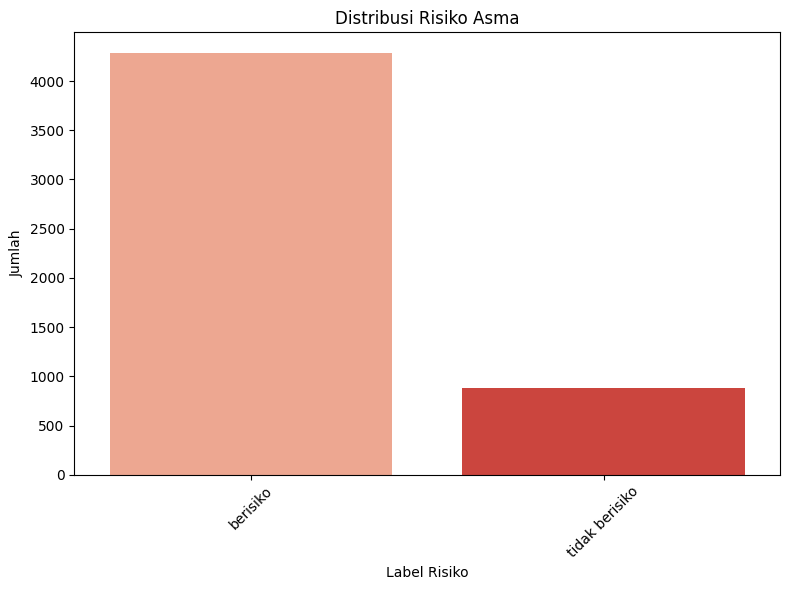

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah masing-masing label risiko
label_counts = data['label_risiko'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds')

plt.title('Distribusi Risiko Asma')
plt.xlabel('Label Risiko')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)  # Jika label panjang
plt.tight_layout()
plt.show()


### **Menentukan Fitur dan Target untuk Klasifikasi & Splitting Data**

In [ ]:
# Fitur dan Target
X = data[["suhu", "kelembapan", "gas"]]
y_rf = data["label_risiko"]       # Untuk klasifikasi risiko
y_nb = data["label_risiko"]       # Untuk klasifikasi risiko

In [ ]:
# Splitting Data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y_rf, test_size=0.2, random_state=42)
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X, y_nb, test_size=0.2, random_state=42)

## **Melatih Model**

### **Training dan Evaluasi Model Random Forest**

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

print("\n Random Forest")
print("Akurasi =", met.accuracy_score(y_test_rf, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf))
print("\nConfusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test_rf, y_pred_rf), index=rf.classes_, columns=rf.classes_))


 Random Forest
Akurasi = 1.0

Classification Report:
                precision    recall  f1-score   support

      berisiko       1.00      1.00      1.00       856
tidak berisiko       1.00      1.00      1.00       176

      accuracy                           1.00      1032
     macro avg       1.00      1.00      1.00      1032
  weighted avg       1.00      1.00      1.00      1032


Confusion Matrix:
                berisiko  tidak berisiko
berisiko             856               0
tidak berisiko         0             176


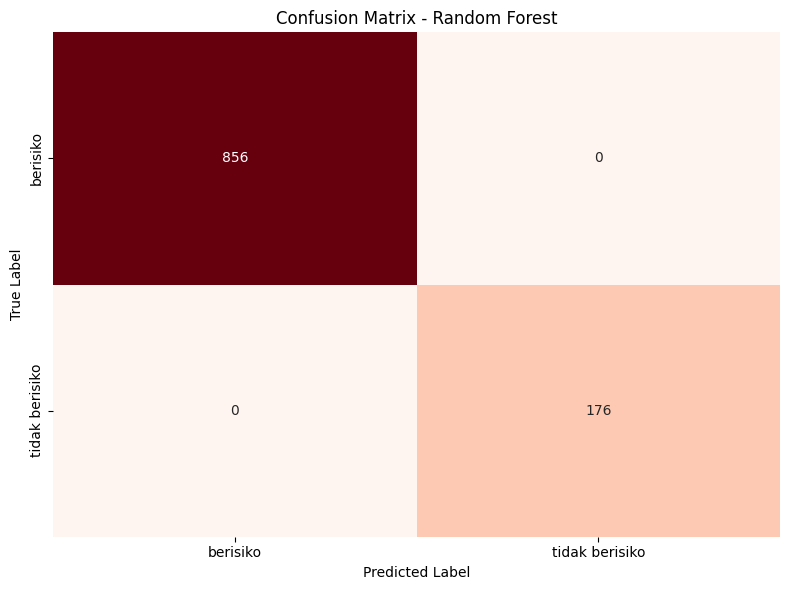

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Membuat confusion matrix
cm = confusion_matrix(y_test_rf, y_pred_rf)
labels = rf.classes_

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels, cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### **Hasil Evaluasi Model Random Forest**

**Akurasi & Classification Report**
1.   **Akurasi = 1.0 atau 100%** (semua prediksi model benar dan tidak ada satu pun kesalahan dalam mengklasifikasi data uji)
2.   **Precision = 1.0** (Model tidak pernah salah mengklasifikasikan)
1.   **Recall = 1.0** (Model selalu mendeteksi semua data dengan benar)
2.   **f1-score = 1.0** (Model seimbang antara presisi dan sensitivitas)

**Confusion Matrix**

Dari 20% dari data (1032 data),
1.   Semua data **berisiko** diprediksi **benar** sebanyak **856 data**
2.   Semua data **tidak berisiko** juga diprediksi **benar** sebanyak **176 data**

### **Training dan Evaluasi Model Naive Bayes**

In [ ]:
nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)
y_pred_nb = nb.predict(X_test_nb)

print("\n Naive Bayes")
print("Akurasi =", met.accuracy_score(y_test_nb, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test_nb, y_pred_nb))
print("\nConfusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test_nb, y_pred_nb), index=nb.classes_, columns=nb.classes_))


 Naive Bayes
Akurasi = 0.9476744186046512

Classification Report:
                precision    recall  f1-score   support

      berisiko       0.99      0.95      0.97       856
tidak berisiko       0.80      0.93      0.86       176

      accuracy                           0.95      1032
     macro avg       0.89      0.94      0.91      1032
  weighted avg       0.95      0.95      0.95      1032


Confusion Matrix:
                berisiko  tidak berisiko
berisiko             814              42
tidak berisiko        12             164


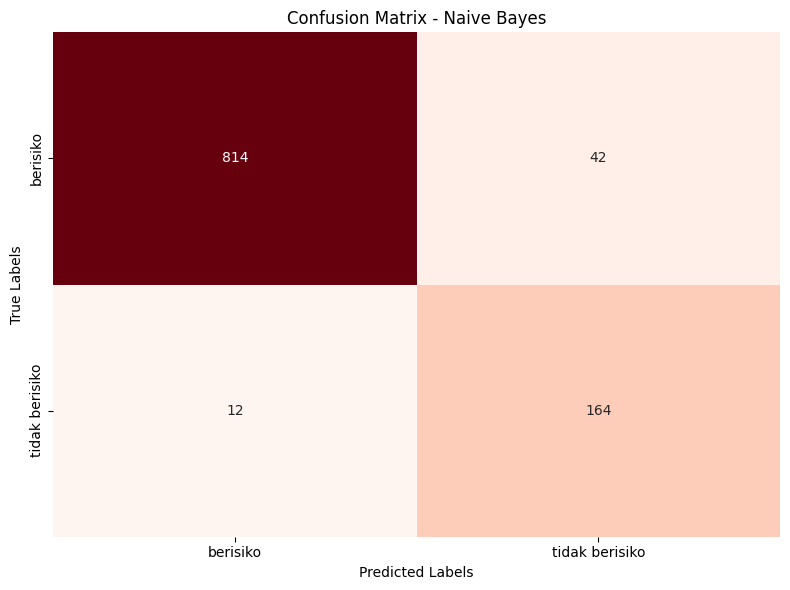

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Asumsikan y_test_nb dan y_pred_nb sudah ada
cm = confusion_matrix(y_test_nb, y_pred_nb)
labels = nb.classes_  # Label dari model Naive Bayes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels, yticklabels=labels, cbar=False)

plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

### **Hasil Evaluasi Model Naive Bayes**

**Akurasi & Classification Report**
1.   **Akurasi = 0.948 atau 94.8%** (hampir 95% prediksi pada data uji berhasil diklasifikasikan dengan benar)

**Kelas "berisiko":**
*   **Precision = 0.99** (Hampir semua prediksi "berisiko" benar)
*   **Recall = 0.95** (Ada sebagian kecil kasus berisiko yang tidak terdeteksi)
*   **f1-score = 0.97** (Keseimbangan antara precision dan recall sangat baik)

**Kelas "tidak berisiko"**
*   **Precision = 0.80** (Beberapa prediksi “tidak berisiko” ternyata salah (false positives))
*   **Recall = 0.93** (Sebagian besar data “tidak berisiko” berhasil dikenali)
*   **f1-score = 0.86** (Masih cukup kuat, tetapi tidak setinggi kelas “berisiko”)

**Macro Avg dan Weighted Avg** menunjukkan performa keseluruhan yang cukup stabil, baik antar kelas maupun secara keseluruhan.

**Confusion Matrix**

Dari 20% dari data (1032 data),
1.   Sebanyak **42 data berisiko** salah diklasifikasikan sebagai **tidak berisiko**
2.   Sebanyak **12 data tidak berisiko** salah diklasifikasikan sebagai **berisiko**

## **Analisis Risiko Asma Berdasarkan Lokasi**

### **Distribusi Risiko Asma per Lokasi**

Menghitung jumlah dan proporsi data dengan label `berisiko` dan `tidak berisiko` untuk masing-masing lokasi.

In [ ]:
print(data.groupby("lokasi")["label_risiko"].value_counts())

lokasi         label_risiko  
food_junction  berisiko          1720
kelas          berisiko          1630
               tidak berisiko      90
library        berisiko           931
               tidak berisiko     789
Name: count, dtype: int64


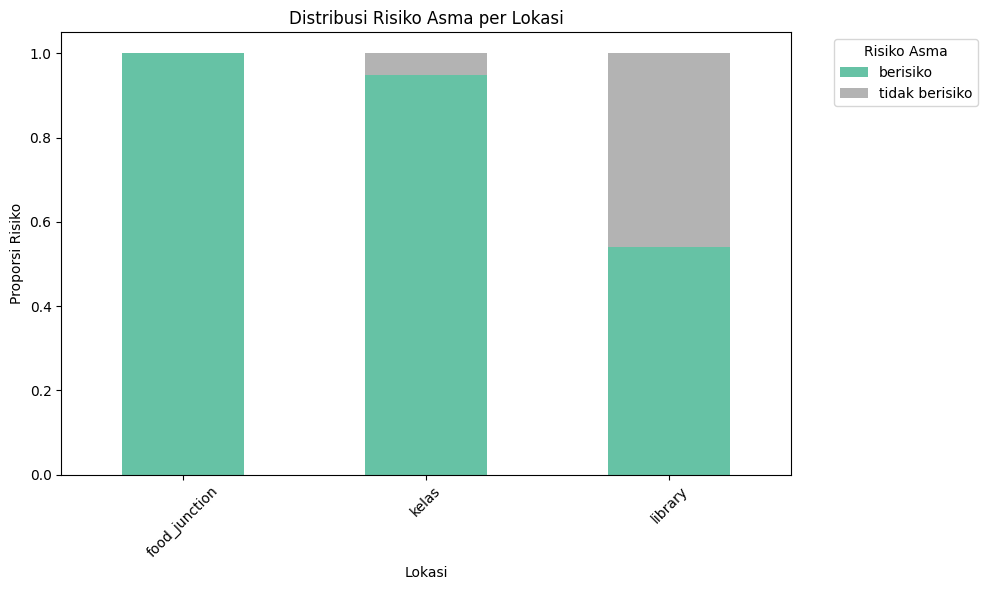

In [ ]:
# Hitung proporsi risiko asma per lokasi
risk_dist = data.groupby("lokasi")["label_risiko"].value_counts(normalize=True).unstack().fillna(0)

# Plot stacked bar chart
risk_dist.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')

plt.title("Distribusi Risiko Asma per Lokasi")
plt.xlabel("Lokasi")
plt.ylabel("Proporsi Risiko")
plt.legend(title="Risiko Asma", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


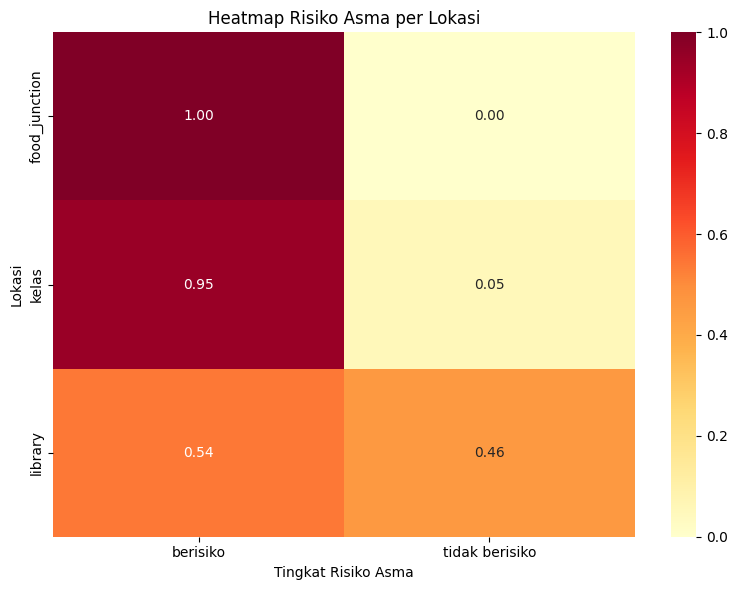

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(risk_dist, annot=True, cmap="YlOrRd", fmt=".2f")

plt.title("Heatmap Risiko Asma per Lokasi")
plt.xlabel("Tingkat Risiko Asma")
plt.ylabel("Lokasi")
plt.tight_layout()
plt.show()

### **Rata-rata Sensor per Lokasi**

Menghitung rata-rata suhu, kelembapan, dan gas di setiap lokasi.

In [ ]:
print("\n Rata-rata sensor per lokasi:")
print(data.groupby("lokasi")[["suhu", "kelembapan", "gas"]].mean())

print("\n Distribusi Risiko Asma per Lokasi:")
print(data.groupby("lokasi")["label_risiko"].value_counts(normalize=True).unstack())


 Rata-rata sensor per lokasi:
                    suhu  kelembapan         gas
lokasi                                          
food_junction  30.167093   68.863372  275.680091
kelas          22.605058   64.383721  213.012209
library        25.810000   61.122093  199.545930

 Distribusi Risiko Asma per Lokasi:
label_risiko   berisiko  tidak berisiko
lokasi                                 
food_junction  1.000000             NaN
kelas          0.947674        0.052326
library        0.541279        0.458721


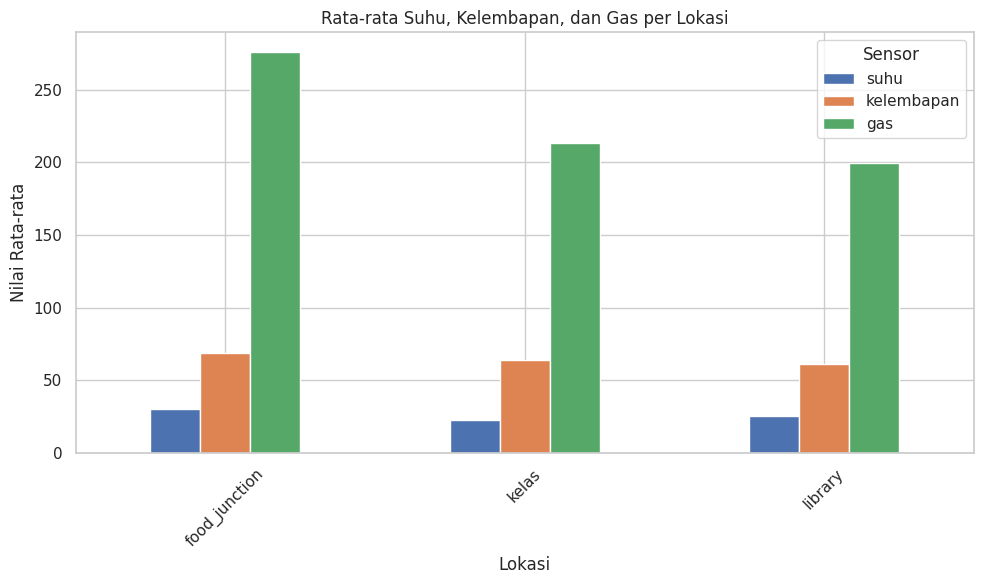

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Barplot: Rata-rata suhu, kelembapan, dan gas per lokasi
avg_sensor = data.groupby("lokasi")[["suhu", "kelembapan", "gas"]].mean().reset_index()

avg_sensor.plot(x="lokasi", kind="bar", figsize=(10,6))
plt.title("Rata-rata Suhu, Kelembapan, dan Gas per Lokasi")
plt.ylabel("Nilai Rata-rata")
plt.xlabel("Lokasi")
plt.xticks(rotation=45)
plt.legend(title="Sensor")
plt.tight_layout()
plt.show()



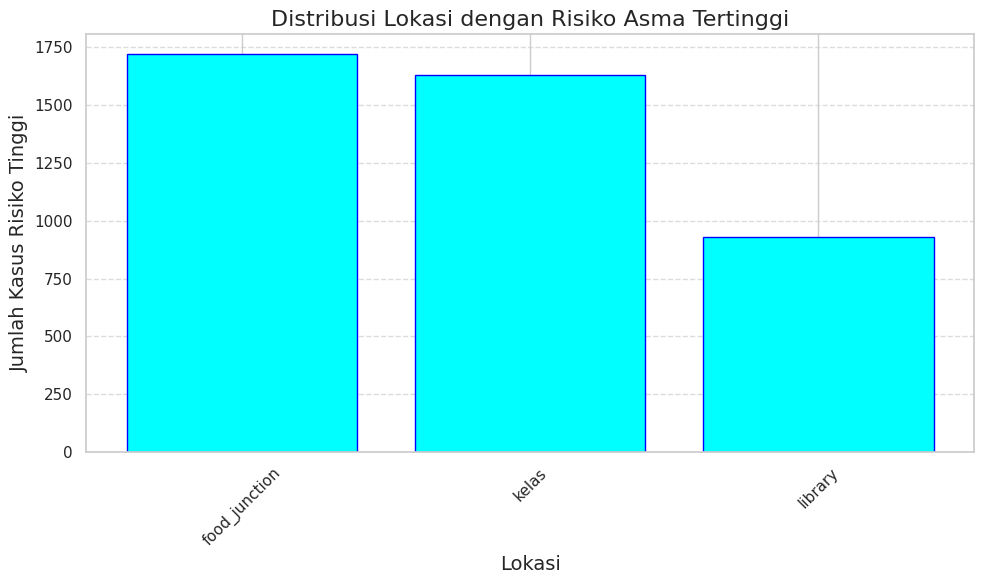

Lokasi dengan kasus risiko asma tinggi terbanyak adalah: food_junction


In [ ]:
import matplotlib.pyplot as plt

# Pastikan kolom yang dibutuhkan ada
if 'lokasi' in data.columns and 'label_risiko' in data.columns:
    # Filter data dengan risiko asma tertentu (misalnya: 'tinggi')
    risiko_tinggi = data[data['label_risiko'] == 'berisiko']

    # Hitung jumlah kemunculan lokasi untuk risiko tinggi
    lokasi_counts = risiko_tinggi['lokasi'].value_counts().sort_index()

    # Plot distribusi lokasi dengan risiko asma tinggi
    plt.figure(figsize=(10, 6))
    plt.bar(lokasi_counts.index, lokasi_counts.values, color='cyan', edgecolor='blue')
    plt.title('Distribusi Lokasi dengan Risiko Asma Tertinggi', fontsize=16)
    plt.xlabel('Lokasi', fontsize=14)
    plt.ylabel('Jumlah Kasus Risiko Tinggi', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Menampilkan lokasi dengan jumlah risiko tinggi terbanyak
    common_lokasi = lokasi_counts.idxmax()
    print(f"Lokasi dengan kasus risiko asma tinggi terbanyak adalah: {common_lokasi}")
else:
    print("Dataset harus memiliki kolom 'lokasi' dan 'risiko_asma'.")


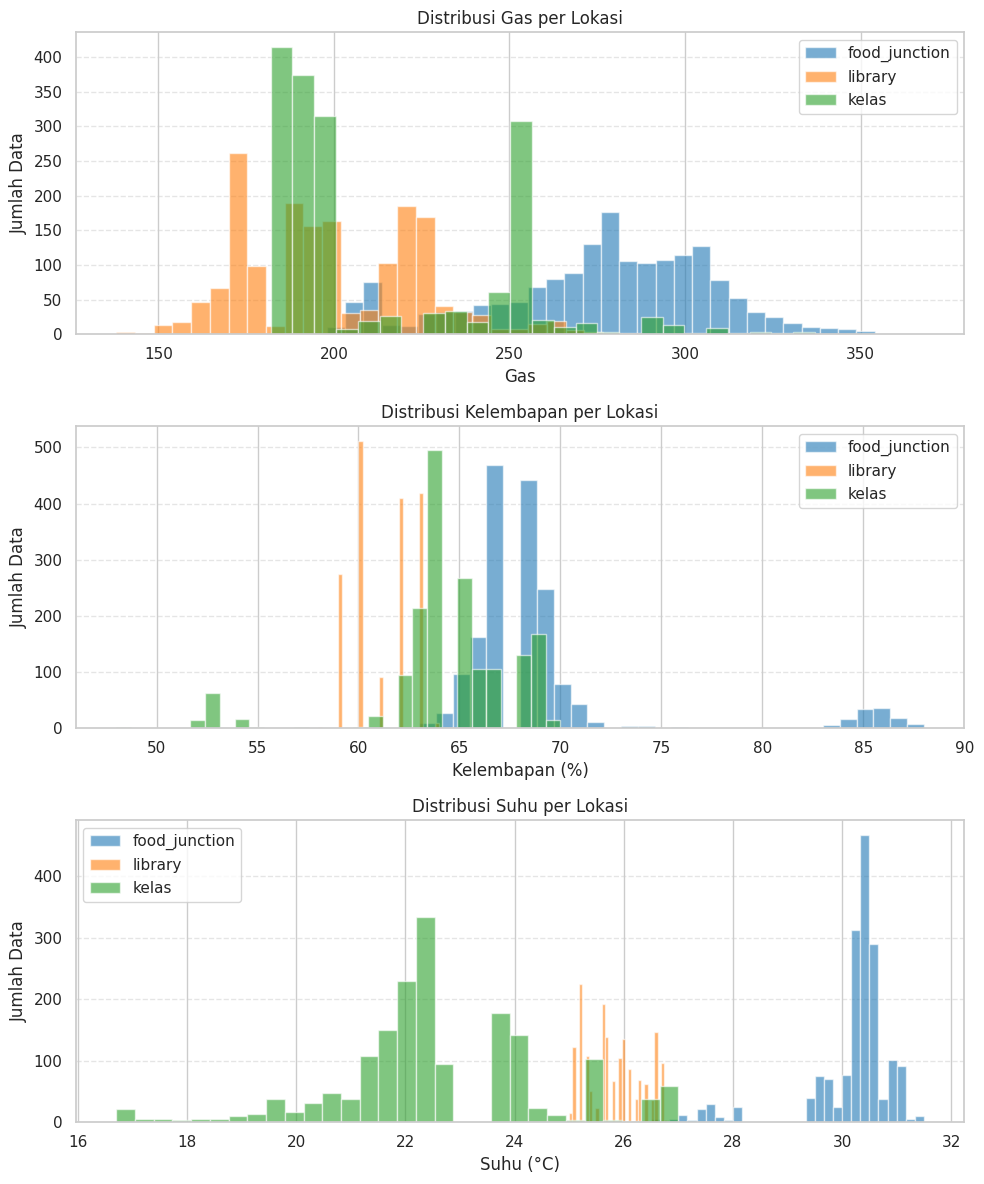

In [ ]:
import matplotlib.pyplot as plt

# Pastikan kolom ada
if all(col in data.columns for col in ['lokasi', 'gas', 'kelembapan', 'suhu']):
    lokasi_unik = data['lokasi'].unique()
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    # Plot distribusi Gas
    for i, lokasi in enumerate(lokasi_unik):
        subset = data[data['lokasi'] == lokasi]
        axes[0].hist(subset['gas'], bins=30, alpha=0.6, label=lokasi, color=colors[i % len(colors)])
    axes[0].set_title('Distribusi Gas per Lokasi')
    axes[0].set_xlabel('Gas')
    axes[0].set_ylabel('Jumlah Data')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Plot distribusi Kelembapan
    for i, lokasi in enumerate(lokasi_unik):
        subset = data[data['lokasi'] == lokasi]
        axes[1].hist(subset['kelembapan'], bins=30, alpha=0.6, label=lokasi, color=colors[i % len(colors)])
    axes[1].set_title('Distribusi Kelembapan per Lokasi')
    axes[1].set_xlabel('Kelembapan (%)')
    axes[1].set_ylabel('Jumlah Data')
    axes[1].legend()
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    # Plot distribusi Suhu
    for i, lokasi in enumerate(lokasi_unik):
        subset = data[data['lokasi'] == lokasi]
        axes[2].hist(subset['suhu'], bins=30, alpha=0.6, label=lokasi, color=colors[i % len(colors)])
    axes[2].set_title('Distribusi Suhu per Lokasi')
    axes[2].set_xlabel('Suhu (°C)')
    axes[2].set_ylabel('Jumlah Data')
    axes[2].legend()
    axes[2].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("Dataset harus memiliki kolom 'lokasi', 'gas', 'kelembapan', dan 'suhu'.")


## **Coba Menggunakan Data Dummy**

Untuk memeriksa apakah model RF dan NB yang telah dibuat memang berhasil/tidak, kami insert 1 data baru yang berisi dummy data

In [ ]:
data = pd.concat([fj, lib, kelas], ignore_index=True)

In [ ]:
data

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp
0,1,29.8,67,316.129176,58:02.4,food_junction,esp8266
1,2,29.8,67,313.697105,58:06.3,food_junction,esp8266
2,3,29.8,67,318.908686,58:11.4,food_junction,esp8266
3,4,29.8,67,312.307350,58:16.6,food_junction,esp8266
4,5,29.8,67,309.527840,58:21.4,food_junction,esp8266
...,...,...,...,...,...,...,...
5155,1784,22.6,69,182.000000,44:40.0,kelas,esp8266
5156,1785,22.6,69,182.000000,44:55.0,kelas,esp8266
5157,1786,22.6,69,182.000000,45:10.2,kelas,esp8266
5158,1787,22.6,69,182.000000,45:25.5,kelas,esp8266


Tambahkan satu baris data dummy ke dalam dataset

In [ ]:
data_dummy = pd.DataFrame([{
    'id': 5161,
    'suhu': 10,
    'kelembapan': 55,
    'gas': 400,
    'waktu': '00:00.0',
    'lokasi': 'dummy',
    'tipe_esp': 'esp8266'
}])

In [ ]:
# Gabungkan dengan dataset utama
data = pd.concat([data, data_dummy], ignore_index=True)

# Tampilkan hasil
data.tail()

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp
5156,1785,22.6,69,182.0,44:55.0,kelas,esp8266
5157,1786,22.6,69,182.0,45:10.2,kelas,esp8266
5158,1787,22.6,69,182.0,45:25.5,kelas,esp8266
5159,1788,22.6,69,182.0,45:40.8,kelas,esp8266
5160,5161,10.0,55,400.0,00:00.0,dummy,esp8266


Data dengan id 5161 adalah data dummy yang telah digabungkan kepada data besar.

In [ ]:
#periksa data duplikat
print('jumlah data yang duplikat:', data.duplicated().sum())

jumlah data yang duplikat: 0


In [ ]:
#missing value
print('jumlah data yang hilang/null')
data.isnull().sum()

jumlah data yang hilang/null


,0
id,0
suhu,0
kelembapan,0
gas,0
waktu,0
lokasi,0
tipe_esp,0


Data dummy tersebut seharusnya **berisiko**, karena untuk `suhu=10` berada **di luar** rentang aman suhu, untuk `kelembapan=55` berada di **dalam** rentang kelembapan, dan untuk `gas=400` berada **di luar** rentang gas.

In [ ]:
# Menambahkan label kualitas suhu
def kualitas_suhu(suhu):
    return 1 if 14.8 <= suhu <= 30 else 0

# Menambahkan label kualitas kelembapan
def kualitas_kelembapan(lembap):
    return 1 if 40 <= lembap <= 60 else 0

# Menambahkan label kualitas gas
def kualitas_gas(gas):
    return 1 if gas < 314 else 0

In [ ]:
data['kualitas_suhu'] = data['suhu'].apply(kualitas_suhu)
data['kualitas_kelembapan'] = data['kelembapan'].apply(kualitas_kelembapan)
data['kualitas_gas'] = data['gas'].apply(kualitas_gas)

In [ ]:
data

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp,kualitas_suhu,kualitas_kelembapan,kualitas_gas
0,1,29.8,67,316.129176,58:02.4,food_junction,esp8266,1,0,0
1,2,29.8,67,313.697105,58:06.3,food_junction,esp8266,1,0,1
2,3,29.8,67,318.908686,58:11.4,food_junction,esp8266,1,0,0
3,4,29.8,67,312.307350,58:16.6,food_junction,esp8266,1,0,1
4,5,29.8,67,309.527840,58:21.4,food_junction,esp8266,1,0,1
...,...,...,...,...,...,...,...,...,...,...
5156,1785,22.6,69,182.000000,44:55.0,kelas,esp8266,1,0,1
5157,1786,22.6,69,182.000000,45:10.2,kelas,esp8266,1,0,1
5158,1787,22.6,69,182.000000,45:25.5,kelas,esp8266,1,0,1
5159,1788,22.6,69,182.000000,45:40.8,kelas,esp8266,1,0,1


In [ ]:
# Lihat struktur data
print("\n Informasi Dataset:")
print(data.info())


 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5161 entries, 0 to 5160
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5161 non-null   int64  
 1   suhu                 5161 non-null   float64
 2   kelembapan           5161 non-null   int64  
 3   gas                  5161 non-null   float64
 4   waktu                5161 non-null   object 
 5   lokasi               5161 non-null   object 
 6   tipe_esp             5161 non-null   object 
 7   kualitas_suhu        5161 non-null   int64  
 8   kualitas_kelembapan  5161 non-null   int64  
 9   kualitas_gas         5161 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 403.3+ KB
None


In [ ]:
# Menambahkan label risiko (1 = aman, 0 = berisiko)
def label_risiko(row):
    if row['kualitas_suhu'] == 1 and row['kualitas_kelembapan'] == 1 and row['kualitas_gas'] == 1:
        return 'tidak berisiko'
    else:
        return 'berisiko'

data['label_risiko'] = data.apply(label_risiko, axis=1)

In [ ]:
data

,id,suhu,kelembapan,gas,waktu,lokasi,tipe_esp,kualitas_suhu,kualitas_kelembapan,kualitas_gas,label_risiko
0,1,29.8,67,316.129176,58:02.4,food_junction,esp8266,1,0,0,berisiko
1,2,29.8,67,313.697105,58:06.3,food_junction,esp8266,1,0,1,berisiko
2,3,29.8,67,318.908686,58:11.4,food_junction,esp8266,1,0,0,berisiko
3,4,29.8,67,312.307350,58:16.6,food_junction,esp8266,1,0,1,berisiko
4,5,29.8,67,309.527840,58:21.4,food_junction,esp8266,1,0,1,berisiko
...,...,...,...,...,...,...,...,...,...,...,...
5156,1785,22.6,69,182.000000,44:55.0,kelas,esp8266,1,0,1,berisiko
5157,1786,22.6,69,182.000000,45:10.2,kelas,esp8266,1,0,1,berisiko
5158,1787,22.6,69,182.000000,45:25.5,kelas,esp8266,1,0,1,berisiko
5159,1788,22.6,69,182.000000,45:40.8,kelas,esp8266,1,0,1,berisiko


Dengan melakukan klasifikasi biasa saja, data dummy tersebut di `label_risiko=berisiko`.

Kami akan mencoba untuk menggunakan model RF dan NB yang akan kita buat menggunakan data besar (seperti diatas) dan test data dummy tersebut.

In [ ]:
print(data['label_risiko'].value_counts())

label_risiko
berisiko          4282
tidak berisiko     879
Name: count, dtype: int64


/tmp/ipython-input-48-1495434622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds')


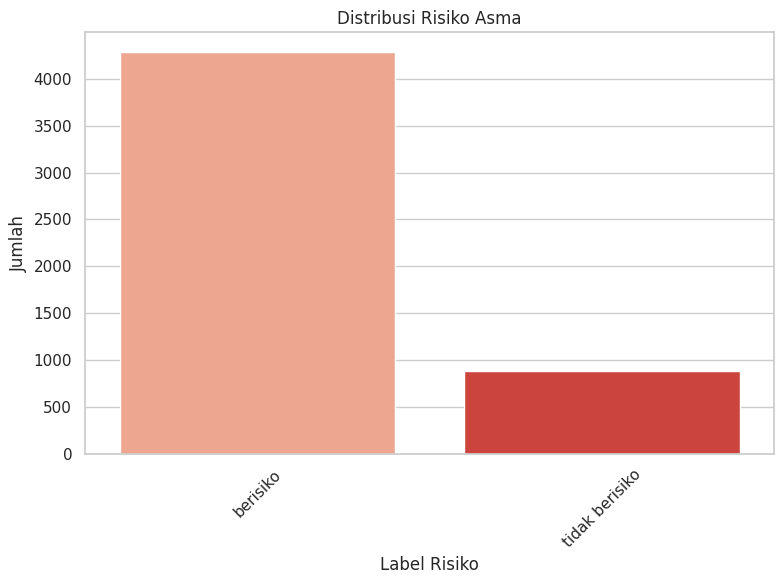

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah masing-masing label risiko
label_counts = data['label_risiko'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds')

plt.title('Distribusi Risiko Asma')
plt.xlabel('Label Risiko')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)  # Jika label panjang
plt.tight_layout()
plt.show()


Data dummy tidak ikut dalam proses pelatihan model (training), sehingga dapat digunakan untuk melihat apakah model benar-benar mampu mengenali kondisi baru yang belum pernah dilihat sebelumnya.

Maka, data dummy akan dipisahkan dulu.

In [ ]:
data_model = data[data['lokasi'] != 'dummy']  # hanya data real

In [ ]:
# Fitur dan Target
X = data[["suhu", "kelembapan", "gas"]]
y_rf = data["label_risiko"]       # Untuk klasifikasi risiko
y_nb = data["label_risiko"]       # Untuk klasifikasi risiko

In [ ]:
# Splitting Data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y_rf, test_size=0.2, random_state=42)
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X, y_nb, test_size=0.2, random_state=42)

Membuat model menggunakan data besar (yang tidak ada data dummy)

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train_rf, y_train_rf)

RandomForestClassifier()

In [ ]:
nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)

GaussianNB()

Di bagian ini, kita **menguji model menggunakan data dummy** yang sebelumnya telah ditambahkan secara manual.

In [ ]:
data_dummy = data[data["lokasi"] == "dummy"]
X_dummy = data_dummy[["suhu", "kelembapan", "gas"]]
y_dummy = data_dummy["label_risiko"]

In [ ]:
pred_rf = rf.predict(X_dummy)
pred_nb = nb.predict(X_dummy)

In [ ]:
print("Prediksi Random Forest:", pred_rf[0])
print("Prediksi Naive Bayes:", pred_nb[0])
print("Label Sebenarnya:", y_dummy.values[0])

Prediksi Random Forest: berisiko
Prediksi Naive Bayes: berisiko
Label Sebenarnya: berisiko


Hasil ini konsisten dengan proses klasifikasi manual yang sebelumnya kita gunakan. Artinya:

1. Model Random Forest dan Naive Bayes **mampu mengenali pola lingkungan yang berisiko** meskipun datanya baru dan tidak pernah dilatih sebelumnya.

2. Ini menunjukkan bahwa **model dapat menggeneralisasi dengan baik**, tidak hanya menghafal data latih, tetapi juga **memahami hubungan antara fitur dan risiko**.